<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/neural_networks/Text_Generation_with_Transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Text generation with transformers (GPT-2)

A **language model** assigns a probability to every possible next token given the text so far. Generating text is then just a loop: predict a distribution, pick a token, append it, repeat. In this lab we open up **GPT-2** (OpenAI, 2019), the model that made this idea famous. We look at how it cuts text into tokens, how many parameters it has and where they are, how it scores sentences, what its attention looks like, and how the choice of decoding strategy turns the same model into a boring or a creative writer.

**Contents**

1. Setup
2. Language modelling in one formula
3. Tokenisation: byte-pair encoding (BPE)
4. Loading GPT-2 and counting its parameters
5. One forward pass: the next-token distribution at every position
6. Scoring text: log-likelihood and perplexity
7. Looking at attention: the causal mask
8. Decoding: greedy search and its problems
9. Faster generation: the key-value cache
10. Sampling: temperature, top-k and top-p, from scratch
11. `model.generate`: beam search and repetition penalties
12. A base model is not an assistant: prompting and few-shot learning
13. Summary and exercises

Theory: [`notes/neural_networks/05_attention_transformers`](https://imagra93.github.io/ML-course-labs/notes/neural_networks/05_attention_transformers.html) (attention, the $\sqrt{d_k}$ scaling, causal masking, the transformer block, a tiny GPT trained from scratch).

**Notation**

| Symbol | Meaning |
|---|---|
| $w_1, \dots, w_T$ | a sequence of $T$ tokens |
| $V = 50{,}257$ | GPT-2 vocabulary size |
| $\mathbf{z}_t \in \mathbb{R}^V$ | logits for the token after position $t$ |
| $p_\theta(w \mid w_{<t})$ | model probability of token $w$ given the previous tokens |
| $d = 768$, $L = 12$, $h = 12$ | model width, number of transformer blocks, attention heads (GPT-2 small) |
| $\tau$ | sampling temperature |

## 1. Setup

This lab uses Hugging Face `transformers`, the maintained successor of the old `pytorch-transformers` package that earlier versions of this lab installed. Colab already has it. GPT-2 small (500 MB) is downloaded on first use. Everything runs on a CPU; a GPU makes generation faster.

In [1]:
import importlib.util, subprocess, sys
if importlib.util.find_spec("transformers") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers"], check=True)

import math, time
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from transformers.utils import logging as hf_logging
hf_logging.set_verbosity_error()
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


## 2. Language modelling in one formula

By the chain rule of probability, the probability of any sequence factorises into next-token probabilities:

$$
p(w_1, \dots, w_T) = \prod_{t=1}^{T} p(w_t \mid w_1, \dots, w_{t-1}) .
$$

A model that estimates every factor $p_\theta(w_t \mid w_{<t})$ is therefore a model of whole texts. GPT-2 is trained to maximise the log-likelihood of its training text, which is the same as minimising the **cross-entropy** of the next-token classification problem, with $V = 50{,}257$ classes:

$$
J(\theta) = -\frac{1}{T}\sum_{t=1}^{T}\log p_\theta(w_t \mid w_{<t}) .
$$

This is exactly the softmax classification of the Fashion-MNIST lab, repeated at every position, with the "label" being the next token of real text. No human annotation is needed: the text supervises itself (**self-supervised learning**). GPT-2 was trained on about 40 GB of web pages (WebText). It is called **autoregressive** because at generation time its own outputs become its next inputs.

## 3. Tokenisation: byte-pair encoding (BPE)

A model works with a fixed vocabulary. Whole words do not work well: the vocabulary would be huge and every new word, typo or name would be unknown. Single characters make sequences very long. **Byte-pair encoding** is the compromise used by GPT models:

1. Start from single characters (GPT-2 actually uses the 256 byte values, so any text in any language can be encoded).
2. Count all pairs of adjacent symbols in the training corpus and **merge the most frequent pair** into a new symbol.
3. Repeat until the vocabulary has the desired size (GPT-2: 50,000 merges).

Frequent words become single tokens, rare words are split into frequent pieces. Here are the first merges on the classic toy corpus:

In [2]:
from collections import Counter

def bpe_merges(word_freqs, n_merges):
    """Learn BPE merges on a {word: count} corpus. Words start as tuples of characters plus an end marker."""
    vocab = {tuple(w) + ("</w>",): c for w, c in word_freqs.items()}
    for step in range(n_merges):
        pairs = Counter()
        for symbols, c in vocab.items():
            for a, b in zip(symbols, symbols[1:]):
                pairs[(a, b)] += c
        (a, b), count = pairs.most_common(1)[0]
        new_vocab = {}
        for symbols, c in vocab.items():
            out, i = [], 0
            while i < len(symbols):
                if i < len(symbols) - 1 and symbols[i] == a and symbols[i + 1] == b:
                    out.append(a + b); i += 2
                else:
                    out.append(symbols[i]); i += 1
            new_vocab[tuple(out)] = c
        vocab = new_vocab
        print(f"merge {step + 1}: {a!r} + {b!r} -> {a + b!r}  (seen {count} times)")
    return vocab

corpus = {"low": 5, "lower": 2, "newest": 6, "widest": 3}
final = bpe_merges(corpus, 8)
print("\nwords after 8 merges:", [" ".join(s) for s in final])

merge 1: 'e' + 's' -> 'es'  (seen 9 times)
merge 2: 'es' + 't' -> 'est'  (seen 9 times)
merge 3: 'est' + '</w>' -> 'est</w>'  (seen 9 times)
merge 4: 'l' + 'o' -> 'lo'  (seen 7 times)
merge 5: 'lo' + 'w' -> 'low'  (seen 7 times)
merge 6: 'n' + 'e' -> 'ne'  (seen 6 times)
merge 7: 'ne' + 'w' -> 'new'  (seen 6 times)
merge 8: 'new' + 'est</w>' -> 'newest</w>'  (seen 6 times)

words after 8 merges: ['low </w>', 'low e r </w>', 'newest</w>', 'w i d est</w>']


"est" becomes a unit because it is shared by "newest" and "widest", and "low" because it is frequent. Real BPE does the same on gigabytes of text.

Now GPT-2's real tokenizer. Two details: a token that starts with a space is shown with the special character `Ġ` (the space is part of the token), and the same word gets a different token depending on whether it is preceded by a space.

In [3]:
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")
print("vocabulary size:", tokenizer.vocab_size, "  end-of-text token:", tokenizer.eos_token, tokenizer.eos_token_id)

examples = [
    "Welcome to the deep learning class",
    "Bienvenidos a la clase de aprendizaje profundo",
    "unbelievably",
    " unbelievably",
    "In 2024 there were 8784 hours, or 527040 minutes.",
    "def square(x): return x ** 2",
]
for text in examples:
    ids = tokenizer.encode(text)
    print(f"{len(text.split()):>2} words -> {len(ids):>2} tokens | {tokenizer.convert_ids_to_tokens(ids)}")

vocabulary size: 50257   end-of-text token: <|endoftext|> 50256
 6 words ->  6 tokens | ['Welcome', 'Ġto', 'Ġthe', 'Ġdeep', 'Ġlearning', 'Ġclass']
 7 words -> 17 tokens | ['B', 'ien', 'ven', 'id', 'os', 'Ġa', 'Ġla', 'Ġcl', 'ase', 'Ġde', 'Ġap', 'rend', 'iz', 'aj', 'e', 'Ġprof', 'undo']
 1 words ->  4 tokens | ['un', 'bel', 'iev', 'ably']
 1 words ->  1 tokens | ['Ġunbelievably']
 9 words -> 14 tokens | ['In', 'Ġ2024', 'Ġthere', 'Ġwere', 'Ġ8', '784', 'Ġhours', ',', 'Ġor', 'Ġ5', '270', '40', 'Ġminutes', '.']
 6 words ->  9 tokens | ['def', 'Ġsquare', '(', 'x', '):', 'Ġreturn', 'Ġx', 'Ġ**', 'Ġ2']


- Common English words are one token each. The Spanish sentence needs many more tokens per word: GPT-2's merges were learned on English text, so Spanish words are split into pieces. A model is more expensive and usually worse in languages that its tokenizer under-represents. Modern multilingual models learn their vocabulary on many languages.
- Numbers are split in irregular chunks, one reason why language models are bad at arithmetic.
- Tokenisation is lossless: `decode(encode(text)) == text`.

## 4. Loading GPT-2 and counting its parameters

`AutoModelForCausalLM` loads the transformer plus the **language-modelling head** that maps each hidden state to $V$ logits. We ask for the "eager" attention implementation so that the model can return its attention weights (section 7).

In [4]:
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2", attn_implementation="eager").to(device)
model.eval()
cfg = model.config
print(f"layers L = {cfg.n_layer}, heads h = {cfg.n_head}, width d = {cfg.n_embd}, context = {cfg.n_positions} tokens, V = {cfg.vocab_size}")
print(model.transformer.h[0])

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

layers L = 12, heads h = 12, width d = 768, context = 1024 tokens, V = 50257
GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
)


**Where are the 124 million parameters?** With $d = 768$:

| Part | Parameters |
|---|---|
| token embeddings $\mathbf{W}_E$ | $V \cdot d$ |
| position embeddings (learned, one per position) | $1024 \cdot d$ |
| per block: attention $\mathbf{W}_{QKV}$ and bias (`c_attn`) | $3d^2 + 3d$ |
| per block: attention output projection (`c_proj`) | $d^2 + d$ |
| per block: MLP $d \to 4d \to d$ (`c_fc`, `c_proj`) | $4d^2 + 4d + 4d^2 + d$ |
| per block: two LayerNorms (scale and shift) | $4d$ |
| final LayerNorm | $2d$ |
| language-modelling head | 0: **tied** to $\mathbf{W}_E$ |

So each block has $12d^2 + 13d$ parameters, and the total is $Vd + 1024d + L(12d^2 + 13d) + 2d$. The output layer reuses the embedding matrix: the logit of token $k$ is the dot product between the final hidden state and the embedding of $k$ (**weight tying**). That saves 38.6 million parameters.

In [5]:
d, L_, V = cfg.n_embd, cfg.n_layer, cfg.vocab_size
formula = V * d + cfg.n_positions * d + L_ * (12 * d**2 + 13 * d) + 2 * d
actual = sum(p.numel() for p in model.parameters())
print(f"formula: {formula:,}   PyTorch: {actual:,}")
print("head tied to embeddings:", model.lm_head.weight.data_ptr() == model.transformer.wte.weight.data_ptr())
parts = {"token embeddings": V * d, "position embeddings": cfg.n_positions * d,
         "attention (12 blocks)": L_ * (4 * d**2 + 4 * d), "MLP (12 blocks)": L_ * (8 * d**2 + 5 * d)}
for k, v in parts.items():
    print(f"  {k:<22} {v:>12,}  ({v / actual:.0%})")

formula: 124,439,808   PyTorch: 124,439,808
head tied to embeddings: True
  token embeddings         38,597,376  (31%)
  position embeddings         786,432  (1%)
  attention (12 blocks)    28,348,416  (23%)
  MLP (12 blocks)          56,669,184  (46%)


Almost a third of GPT-2 small is its vocabulary table, and the MLPs hold twice as many parameters as the attention layers. In large models the $12d^2$ term dominates everything.

## 5. One forward pass: the next-token distribution at every position

For an input of $T$ tokens, GPT-2 returns logits of shape $(1, T, V)$: at **every** position $t$ it predicts the token $t + 1$. During training all $T$ predictions are scored at once, which makes training very efficient. During generation only the last one is needed.

In [6]:
text = "Welcome to the deep learning class, it is a"
ids = tokenizer.encode(text, return_tensors="pt").to(device)
with torch.no_grad():
    logits = model(ids).logits
print("input ids:", ids.shape, " logits:", tuple(logits.shape), "(batch, positions, vocabulary)")

tokens = tokenizer.convert_ids_to_tokens(ids[0])
for t in range(ids.shape[1]):
    best = logits[0, t].argmax().item()
    print(f"after {tokenizer.decode(ids[0, :t + 1])!r:<48} -> predicts {tokenizer.decode(best)!r}")

input ids: torch.Size([1, 10])  logits: (1, 10, 50257) (batch, positions, vocabulary)
after 'Welcome'                                        -> predicts ' to'
after 'Welcome to'                                     -> predicts ' the'
after 'Welcome to the'                                 -> predicts ' latest'
after 'Welcome to the deep'                            -> predicts ' web'
after 'Welcome to the deep learning'                   -> predicts ' community'
after 'Welcome to the deep learning class'             -> predicts '.'
after 'Welcome to the deep learning class,'            -> predicts ' where'
after 'Welcome to the deep learning class, it'         -> predicts "'s"
after 'Welcome to the deep learning class, it is'      -> predicts ' a'
after 'Welcome to the deep learning class, it is a'    -> predicts ' great'


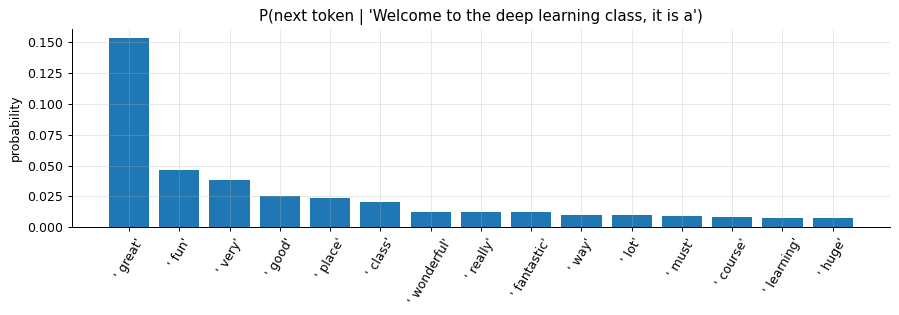

the 15 most likely tokens hold 39.7% of the probability; entropy = 5.74 nats (uniform over V would be 10.82)


In [7]:
probs = torch.softmax(logits[0, -1], dim=-1)
top = torch.topk(probs, 15)
fig, ax = plt.subplots(figsize=(10, 3.6))
ax.bar([repr(tokenizer.decode(i)) for i in top.indices.tolist()], top.values.cpu().numpy())
ax.set_ylabel("probability"); ax.tick_params(axis="x", rotation=60)
ax.set_title(f"P(next token | {text!r})")
plt.tight_layout(); plt.show()
entropy = -(probs * torch.log(probs + 1e-12)).sum().item()
print(f"the 15 most likely tokens hold {top.values.sum():.1%} of the probability; entropy = {entropy:.2f} nats "
      f"(uniform over V would be {math.log(V):.2f})")

The distribution is spread out: " great" is the favourite, but many continuations are plausible. How we choose among them is the **decoding** problem of sections 8 to 11.

## 6. Scoring text: log-likelihood and perplexity

The same model that generates text can **score** it. The log-probability of a text is the sum of the log-probabilities of its tokens, and the mean negative log-probability is exactly the training loss $J$. Its exponential is the **perplexity**:

$$
\text{PPL} = \exp\Big(-\frac{1}{T}\sum_{t}\log p_\theta(w_t \mid w_{<t})\Big) .
$$

Interpretation: a perplexity of 20 means the model is, on average, as uncertain as if it had to choose uniformly among 20 tokens at each step. Lower is better. A uniform guess over the vocabulary has perplexity $V = 50{,}257$.

We compute it by hand from the logits (the prediction at position $t$ is compared with the token at $t + 1$) and check against the loss that `transformers` returns when we pass `labels`.

In [8]:
def token_logprobs(text):
    ids = tokenizer.encode(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(ids).logits
    logp = torch.log_softmax(logits[0, :-1], dim=-1)            # predictions for tokens 2..T
    return ids[0, 1:], logp.gather(1, ids[0, 1:, None])[:, 0]    # log p(w_t | w_<t) for t = 2..T

def perplexity(text):
    _, lp = token_logprobs(text)
    return math.exp(-lp.mean().item())

s = "The cat sat on the mat and looked out of the window."
ids = tokenizer.encode(s, return_tensors="pt").to(device)
with torch.no_grad():
    hf_loss = model(ids, labels=ids).loss.item()
print(f"by hand: PPL = {perplexity(s):.2f}   transformers loss -> PPL = {math.exp(hf_loss):.2f}\n")

sentences = {
    "natural English":   "The cat sat on the mat and looked out of the window.",
    "same words, shuffled": "Window the mat of cat the out on and sat looked the.",
    "Spanish":           "El gato se sentó en la alfombra y miró por la ventana.",
    "fact":              "Paris is the capital of France.",
    "false fact":        "Paris is the capital of Germany.",
}
for name, sent in sentences.items():
    print(f"{name:<22} PPL {perplexity(sent):>9.1f}   {sent}")

by hand: PPL = 21.74   transformers loss -> PPL = 21.74

natural English        PPL      21.7   The cat sat on the mat and looked out of the window.
same words, shuffled   PPL    1535.5   Window the mat of cat the out on and sat looked the.
Spanish                PPL     235.4   El gato se sentó en la alfombra y miró por la ventana.
fact                   PPL      15.8   Paris is the capital of France.
false fact             PPL      17.8   Paris is the capital of Germany.


- Shuffling the same words multiplies the perplexity by about 70: the model has learned **grammar and word order**, not just word frequencies.
- Spanish is far less likely than English: GPT-2 saw little Spanish.
- The false fact gets a higher perplexity than the true one, but only slightly. The model has absorbed some **world knowledge** from its training text, as statistics about which words go together. It does not "know" facts, and it will happily generate false ones.

**Per-token surprisal.** $-\log_2 p(w_t \mid w_{<t})$ measures how surprising each token is, in bits. It shows exactly where a sentence stops making sense to the model.

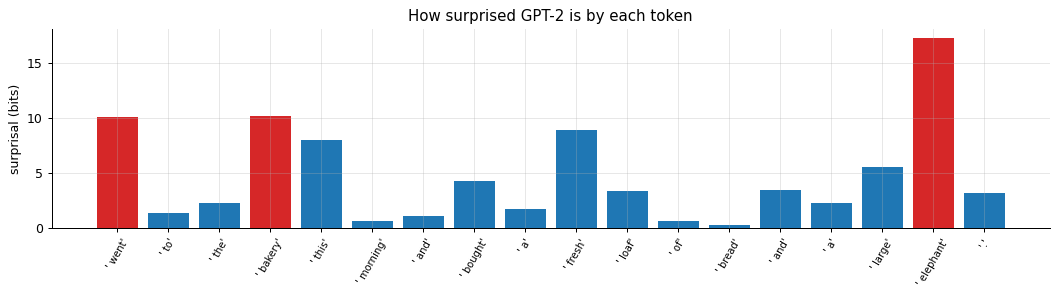

In [9]:
s = "I went to the bakery this morning and bought a fresh loaf of bread and a large elephant."
tgt, lp = token_logprobs(s)
surprisal = (-lp / math.log(2)).cpu().numpy()
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.bar(range(len(surprisal)), surprisal, color=["C3" if v > 10 else "C0" for v in surprisal])
ax.set_xticks(range(len(surprisal))); ax.set_xticklabels([repr(tokenizer.decode(t)) for t in tgt.tolist()], rotation=60, fontsize=8)
ax.set_ylabel("surprisal (bits)"); ax.set_title("How surprised GPT-2 is by each token")
plt.tight_layout(); plt.show()

The predictable tokens ("loaf of **bread**") cost almost nothing, while "elephant" after "a large" in a bakery is very surprising. Early content words such as "went" and "bakery" are also costly: with only a few words of context, many continuations are possible. Perplexity-style scores are used in practice to rank candidate answers, detect unusual text and evaluate language models.

## 7. Looking at attention: the causal mask

Inside each block, every position computes a **query**, a **key** and a **value** vector. Position $i$ attends to position $j$ with weight

$$
a_{ij} = \text{softmax}_j\Big(\frac{\mathbf{q}_i^\top\mathbf{k}_j}{\sqrt{d_k}} + m_{ij}\Big), \qquad m_{ij} = \begin{cases} 0 & j \le i \\ -\infty & j > i \end{cases}
$$

and its output is $\sum_j a_{ij}\mathbf{v}_j$. The **causal mask** $m_{ij}$ forbids looking at future tokens, so the prediction at position $i$ can only use tokens $1..i$. That is what makes it legitimate to train all positions at once. Each of the 12 heads in each of the 12 layers has its own attention pattern. We plot a few of them.

attention tensor: (12, 12, 13, 13) (layers, heads, query position, key position)
max weight on future positions: 0.0
each row sums to 1: True


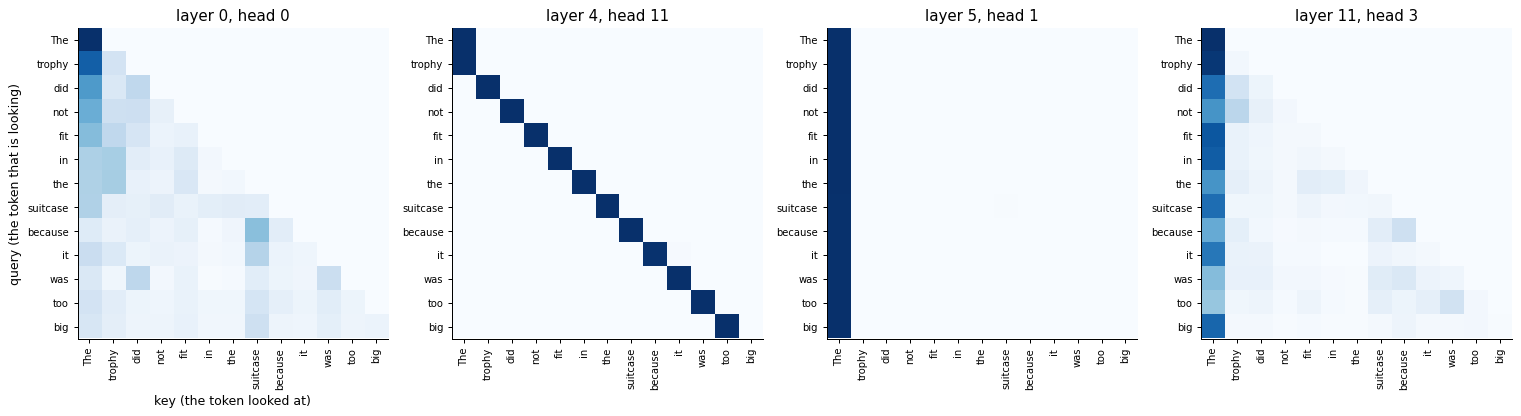

In [10]:
text = "The trophy did not fit in the suitcase because it was too big"
ids = tokenizer.encode(text, return_tensors="pt").to(device)
with torch.no_grad():
    out = model(ids, output_attentions=True)
att = torch.stack(out.attentions)[:, 0].cpu()            # (layers, heads, T, T)
toks = [tokenizer.decode(t).strip() or "_" for t in ids[0].tolist()]
print("attention tensor:", tuple(att.shape), "(layers, heads, query position, key position)")
print("max weight on future positions:", att.triu(diagonal=1).max().item())
print("each row sums to 1:", torch.allclose(att.sum(-1), torch.ones(1)))

fig, axes = plt.subplots(1, 4, figsize=(17, 4.4))
for ax, (l, h) in zip(axes, [(0, 0), (4, 11), (5, 1), (11, 3)]):
    ax.imshow(att[l, h], cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(toks))); ax.set_xticklabels(toks, rotation=90, fontsize=8)
    ax.set_yticks(range(len(toks))); ax.set_yticklabels(toks, fontsize=8)
    ax.set_title(f"layer {l}, head {h}"); ax.grid(False)
axes[0].set_ylabel("query (the token that is looking)"); axes[0].set_xlabel("key (the token looked at)")
plt.tight_layout(); plt.show()

- The upper triangle is exactly zero: no position can see the future.
- Heads specialise. Some attend to the previous token, some spread attention broadly, many put a lot of weight on the **first token**, which works as a default "nothing relevant here" slot (an *attention sink*).
- Individual attention maps must be interpreted with care: the final prediction combines 144 heads and the MLPs, and a single map rarely explains a decision on its own.

What does the model predict after "because it was too big"? We can check what it thinks "it" refers to by comparing continuations:

In [11]:
for ending in [" The trophy was too big.", " The suitcase was too big."]:
    print(f"PPL of '{text}.{ending}': {perplexity(text + '.' + ending):.1f}")

PPL of 'The trophy did not fit in the suitcase because it was too big. The trophy was too big.': 21.9
PPL of 'The trophy did not fit in the suitcase because it was too big. The suitcase was too big.': 20.5


This is a *Winograd schema*: resolving "it" needs world knowledge (big things do not fit into small ones), so the correct reading is "the trophy was too big". Here GPT-2 slightly prefers the **wrong** continuation. Small models get many such cases wrong, and a single example proves little either way; large models solve most of them.

## 8. Decoding: greedy search and its problems

The simplest strategy is **greedy decoding**: always append the most probable token, $w_{t+1} = \arg\max_w p_\theta(w \mid w_{\le t})$. Here is the loop written by hand.

In [12]:
def greedy(prompt, n_tokens=40):
    ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    for _ in range(n_tokens):
        with torch.no_grad():
            logits = model(ids).logits[0, -1]               # distribution for the next token only
        next_id = logits.argmax().view(1, 1)
        ids = torch.cat([ids, next_id], dim=1)               # append and feed back in
    return tokenizer.decode(ids[0])

print(greedy("Studying the MINT master is the best decision I", 40))
print("\n---\n")
print(greedy("The key to training neural networks is", 60))

Studying the MINT master is the best decision I've ever made.

I'm not sure if I'm going to be able to do it, but I'm going to be able to do it.

I'm going to be able

---



The key to training neural networks is to train them to recognize the world around them.

"We're not going to be able to do that with the human brain," says Dr. Michael J. Schoenfeld, a neuroscientist at the University of California, San Diego. "We're going to have to train them


Greedy text starts well and then **loops**. Once a phrase has been generated, repeating it becomes the most probable continuation, and greedy decoding can never escape. It is also not the most probable *sequence*: choosing the best token at each step can lead to a worse sentence overall.

There are two families of fixes: search for high-probability sequences more carefully (beam search, section 11), or **sample** (section 10). Before that, a practical point about speed.

## 9. Faster generation: the key-value cache

The greedy loop re-runs the whole prefix through the model at every step, so generating $n$ tokens costs $O(n^2)$ token computations. But because of the causal mask, the keys and values of old tokens **never change** when new tokens are appended. We can compute them once and keep them: the **KV cache**. Each new step then only processes the one new token. `transformers` returns the cache as `past_key_values`.

In [13]:
def greedy_ids(prompt, n_tokens, use_cache):
    ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    past, step_input, out_ids = None, ids, ids
    for _ in range(n_tokens):
        with torch.no_grad():
            out = model(step_input if use_cache else out_ids, past_key_values=past, use_cache=use_cache)
        next_id = out.logits[0, -1].argmax().view(1, 1)
        out_ids = torch.cat([out_ids, next_id], dim=1)
        if use_cache:
            past, step_input = out.past_key_values, next_id   # only the new token goes in next time
    return out_ids

prompt = "The history of machine learning " * 40                  # a long prompt: 200 tokens
n_prompt, n_new = len(tokenizer.encode(prompt)), 200
for use_cache in [False, True]:
    t0 = time.time(); ids_out = greedy_ids(prompt, n_new, use_cache); dt = time.time() - t0
    processed = n_new if use_cache else sum(n_prompt + k for k in range(n_new))
    processed += n_prompt if use_cache else 0
    print(f"use_cache={use_cache!s:<5}: {dt:.2f}s for {n_new} new tokens, {processed:,} token positions processed")
same = torch.equal(greedy_ids(prompt, 30, False), greedy_ids(prompt, 30, True))
print("identical output with and without cache:", same)

use_cache=False: 0.88s for 200 new tokens, 60,100 token positions processed


use_cache=True : 0.72s for 200 new tokens, 401 token positions processed


identical output with and without cache: True


Same output, far fewer token positions processed. On a GPU and for a model this small the wall-clock gain can be modest, because each step is dominated by fixed overheads and the GPU processes a few hundred positions in parallel almost for free. On a CPU, for longer contexts or for bigger models, the difference is large. Every production LLM uses a KV cache, and its memory, which grows with the context length, is one of the main costs of serving long conversations.

## 10. Sampling: temperature, top-k and top-p, from scratch

Instead of taking the argmax we can **sample** the next token from the distribution. Three knobs shape that distribution first.

**Temperature** $\tau$ divides the logits before the softmax:

$$
p_\tau(w) = \frac{\exp(z_w / \tau)}{\sum_{w'}\exp(z_{w'} / \tau)} \;\propto\; p(w)^{1/\tau} .
$$

$\tau \to 0$ puts all mass on the argmax (greedy), $\tau = 1$ is the model's distribution, $\tau > 1$ flattens it (more diverse, less coherent).

**Top-k**: keep only the $k$ most probable tokens, renormalise, sample. **Top-p** (nucleus sampling, Holtzman et al., 2019): keep the smallest set of tokens whose total probability reaches $p$. When the model is confident the set is small, when it is unsure the set is large, which adapts better than a fixed $k$.

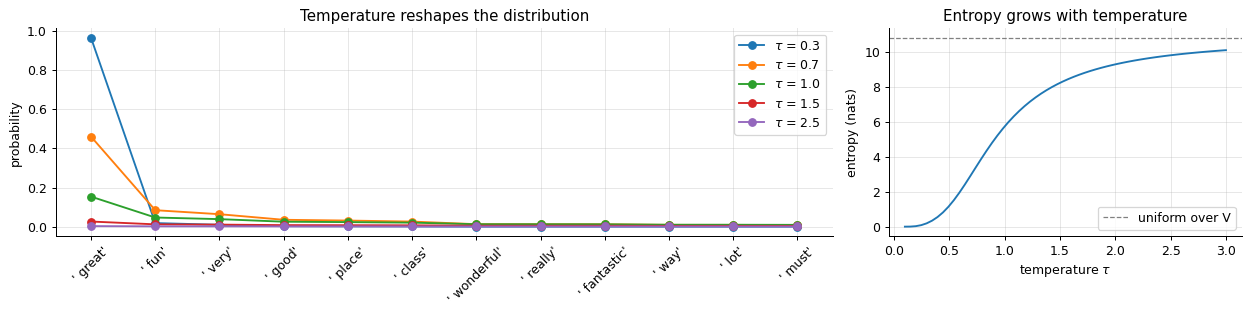

In [14]:
z = logits_last = model(tokenizer.encode("Welcome to the deep learning class, it is a", return_tensors="pt").to(device)).logits[0, -1].detach()
taus = [0.3, 0.7, 1.0, 1.5, 2.5]
fig, axes = plt.subplots(1, 2, figsize=(14, 3.6), gridspec_kw={"width_ratios": [2.2, 1]})
top_ids = torch.topk(z, 12).indices
for tau in taus:
    p = torch.softmax(z / tau, dim=-1)
    axes[0].plot(range(12), p[top_ids].cpu(), "o-", label=rf"$\tau$ = {tau}")
axes[0].set_xticks(range(12)); axes[0].set_xticklabels([repr(tokenizer.decode(i)) for i in top_ids.tolist()], rotation=45)
axes[0].set_ylabel("probability"); axes[0].legend(); axes[0].set_title("Temperature reshapes the distribution")
ts = np.linspace(0.1, 3, 60)
ent = [-(torch.softmax(z / t, -1) * torch.log_softmax(z / t, -1)).sum().item() for t in ts]
axes[1].plot(ts, ent); axes[1].axhline(math.log(V), color="gray", ls="--", lw=1, label="uniform over V")
axes[1].set_xlabel(r"temperature $\tau$"); axes[1].set_ylabel("entropy (nats)"); axes[1].legend()
axes[1].set_title("Entropy grows with temperature")
plt.tight_layout(); plt.show()

In [15]:
def filter_logits(logits, top_k=None, top_p=None):
    """Set to -inf every logit outside the top-k and/or the top-p nucleus."""
    logits = logits.clone()
    if top_k is not None:
        kth = torch.topk(logits, top_k).values[-1]
        logits[logits < kth] = -float("inf")
    if top_p is not None:
        sorted_logits, order = torch.sort(logits, descending=True)
        cum = torch.softmax(sorted_logits, dim=-1).cumsum(dim=-1)
        remove = cum - torch.softmax(sorted_logits, dim=-1) >= top_p     # tokens after the nucleus is complete
        logits[order[remove]] = -float("inf")
    return logits

def sample(prompt, n_tokens=40, temperature=1.0, top_k=None, top_p=None, seed=0):
    g = torch.Generator(device=device).manual_seed(seed)
    ids = tokenizer.encode(prompt, return_tensors="pt").to(device)
    past, step_input = None, ids
    for _ in range(n_tokens):
        with torch.no_grad():
            out = model(step_input, past_key_values=past, use_cache=True)
        logits = filter_logits(out.logits[0, -1] / temperature, top_k, top_p)
        next_id = torch.multinomial(torch.softmax(logits, dim=-1), 1, generator=g).view(1, 1)
        ids = torch.cat([ids, next_id], dim=1)
        past, step_input = out.past_key_values, next_id
    return tokenizer.decode(ids[0])

p = torch.softmax(z, -1)
for top_p in [0.5, 0.9]:
    kept = torch.isfinite(filter_logits(z, top_p=top_p)).sum().item()
    print(f"top-p = {top_p}: the nucleus has {kept} tokens for this prompt")

top-p = 0.5: the nucleus has 35 tokens for this prompt
top-p = 0.9: the nucleus has 977 tokens for this prompt


In [16]:
prompt = "Studying the MINT master is the best decision I"
settings = [
    ("temperature 0.1 (almost greedy)", dict(temperature=0.1)),
    ("temperature 1.0, no filter",       dict(temperature=1.0)),
    ("temperature 1.8, no filter",       dict(temperature=1.8)),
    ("temperature 0.8, top-k = 40",      dict(temperature=0.8, top_k=40)),
    ("temperature 0.9, top-p = 0.9",     dict(temperature=0.9, top_p=0.9)),
]
for name, kw in settings:
    print(f"=== {name}")
    for seed in range(2):
        print(f"[seed {seed}]", sample(prompt, 35, seed=seed, **kw).replace("\n", " "))
    print()

=== temperature 0.1 (almost greedy)
[seed 0] Studying the MINT master is the best decision I've ever made. I'm not sure if I'm going to be able to do it, but I'm going to be able to do it. I'm going to be


[seed 1] Studying the MINT master is the best decision I've ever made. I'm not sure if I'm going to be able to do it, but I'm going to be able to do it. I'm going to be

=== temperature 1.0, no filter
[seed 0] Studying the MINT master is the best decision I ever made. I think that results in perfection to finally be aware of the MINT master together with my personal garbage. I will check that balance when I make the Bill for


[seed 1] Studying the MINT master is the best decision I've made to date. You should start with the one that absolutely 101SDART is low profile and highest quality. You really only want to pick it up with a parallel called

=== temperature 1.8, no filter
[seed 0] Studying the MINT master is the best decision I ever makes. ...olla refund results:y cookrentice Orc tattoo worker Clay Destroyer Gotan togethericipsiecer garbage wars Maul Kimcos marmultchal Junior wowaffle Bill Sox


[seed 1] Studying the MINT master is the best decision I've made'. Explanequde!". SaTUNE Queen Orc Summoner 101negativede Franco Dance Modexc highest obligant Slug really technical+project Pros Copy Uriel 1983 unfortunately parallel called

=== temperature 0.8, top-k = 40
[seed 0] Studying the MINT master is the best decision I ever made. I think that is the reason why you have to study the MINT master. You must study the MINT master to be successful. If you fail to do


[seed 1] Studying the MINT master is the best decision I've made in my life since my first experience with the system. I didn't realize how much the MINT system has really helped me. After starting with it, I'm

=== temperature 0.9, top-p = 0.9
[seed 0] Studying the MINT master is the best decision I ever made. I think that is the point of building software.  Software is the single most important thing you can learn. It is like a mathematical concept for learning math


[seed 1] Studying the MINT master is the best decision I've made to date. You should start with the one that comes closest to you. Because sometimes an Amazon or B&H expert will ask you a few questions you can't



- At $\tau = 0.1$ both seeds give (almost) the same greedy text, loops included.
- At $\tau = 1.8$ without filtering, the long tail of 50,000 unlikely tokens gets real probability and the text quickly derails into nonsense.
- **Top-k and top-p cut the tail** while keeping variety. Temperature around 0.7 to 1 with top-p around 0.9 is a common default for creative text. For factual or code answers, lower temperatures are used.

## 11. `model.generate`: beam search and repetition penalties

Everything above is available in one call. `model.generate` implements greedy, sampling, top-k, top-p and **beam search**: keep the $B$ most probable partial sequences at every step instead of one, and return the most probable complete sequence found. It also offers fixes for repetition:
- `no_repeat_ngram_size=n` forbids generating any $n$-gram that already appears;
- `repetition_penalty` divides the logits of tokens that were already generated (Keskar et al., 2019).

In [17]:
prompt = "The key to training neural networks is"
enc = tokenizer(prompt, return_tensors="pt").to(device)
configs = {
    "greedy":                       dict(do_sample=False),
    "beam search (5 beams)":        dict(do_sample=False, num_beams=5),
    "beam search + no_repeat_ngram": dict(do_sample=False, num_beams=5, no_repeat_ngram_size=3),
    "greedy + repetition_penalty":  dict(do_sample=False, repetition_penalty=1.3),
    "top-p sampling":               dict(do_sample=True, top_p=0.9, temperature=0.9),
}
for name, kw in configs.items():
    torch.manual_seed(0)
    out = model.generate(**enc, max_new_tokens=45, pad_token_id=tokenizer.eos_token_id, **kw)
    print(f"=== {name}\n{tokenizer.decode(out[0], skip_special_tokens=True)}\n".replace("\n\n", " ").replace("\n", " ") + "\n")

=== greedy The key to training neural networks is to train them to recognize the world around them. "We're not going to be able to do that with the human brain," says Dr. Michael J. Schoenfeld, a neuroscientist at the University 



=== beam search (5 beams) The key to training neural networks is to train them in a way that allows them to learn from each other. In this article, I'll show you how to train neural networks to learn from each other. I'll also show you how to train neural 



=== beam search + no_repeat_ngram The key to training neural networks is to train them in a way that allows them to learn from each other. In this post, I'll show you how to train a neural network to learn a new word. I'll also show you a way to 

=== greedy + repetition_penalty The key to training neural networks is the ability of a network's neurons, which are connected by connections between them and their neighbors. "We have been able for some time now that we can train these systems on different kinds (of information) in order not 



=== top-p sampling The key to training neural networks is to recognize and adapt their inputs. We can use neural networks to learn to recognize input cues and to identify which signals will be used for training. As with any human training, training networks are trained by a set of 



Beam search finds sequences with higher total probability than greedy, but high-probability text is often **bland and repetitive** in open-ended generation (the "likelihood trap"). It works best when the output is tightly constrained by the input, as in translation or summarisation. For open-ended text, sampling with top-p is preferred.

## 12. A base model is not an assistant: prompting and few-shot learning

GPT-2 is a **base model**: it only continues text in the style of web pages. It has no notion of "answering" and "stopping". Ask it a question and it may answer, continue with more questions, or ramble, depending on what usually follows such text on the web.

In [18]:
def complete(prompt, n=15):
    enc = tokenizer(prompt, return_tensors="pt").to(device)
    out = model.generate(**enc, max_new_tokens=n, do_sample=False, pad_token_id=tokenizer.eos_token_id)
    return tokenizer.decode(out[0, enc["input_ids"].shape[1]:])

print("zero-shot:", repr(complete("What is the capital of France?")))
few_shot = ("Q: What is the capital of Italy?\nA: Rome\n"
            "Q: What is the capital of Japan?\nA: Tokyo\n"
            "Q: What is the capital of France?\nA:")
print("few-shot: ", repr(complete(few_shot, 4)))
translate = "English: cat\nFrench: chat\nEnglish: dog\nFrench: chien\nEnglish: house\nFrench:"
print("few-shot translation:", repr(complete(translate, 3)))

zero-shot: '\n\nThe capital of France is Paris.\n\nThe capital of France'
few-shot:  ' Paris\nQ:'
few-shot translation: ' house\nFrench'


- Zero-shot, GPT-2 produces the right fact but then keeps going, repeating itself: nothing tells it that the answer is complete.
- With a few examples in the prompt, the pattern "Q: ... A: short answer" becomes the most likely continuation. The model answers in the requested format and immediately starts the next "Q:". This is **in-context learning** (few-shot prompting): no weights change, the task is specified by the prompt.
- The translation prompt fails: GPT-2 small just copies "house". In-context learning is weak in small models. GPT-3 (175 billion parameters, 1,400 times GPT-2 small) showed that it grows dramatically with scale.

Chat assistants add two training stages on top of a base model like this one: **instruction tuning** (supervised fine-tuning on examples of instructions and good answers) and **preference optimisation** (for example RLHF, reinforcement learning from human feedback). The RAG lab uses a small instruction-tuned model.

## 13. Summary

- A language model factorises $p(w_1..w_T) = \prod_t p(w_t \mid w_{<t})$ and is trained with the next-token cross-entropy, on raw text.
- **BPE** builds a subword vocabulary by repeatedly merging the most frequent pair. Tokenisation decides the cost and quality of a model in each language.
- GPT-2 small: 12 blocks of width 768, $Vd + 1024d + L(12d^2 + 13d) + 2d = 124$M parameters, output layer tied to the embeddings.
- The model outputs a next-token distribution at every position. The mean negative log-likelihood is the loss, its exponential the **perplexity**.
- **Causal self-attention** lets each position look only at earlier positions. Heads learn different patterns.
- **Decoding** turns distributions into text: greedy (repetitive), beam search (high probability, bland), sampling with temperature, top-k, top-p (diverse). The **KV cache** makes generation linear in length.
- A base model continues text. Few-shot prompts steer it; instruction tuning and RLHF turn it into an assistant.

## Exercises

Try each one before opening the answer.

1. **Autoregressive vs masked language models.** GPT-2 predicts the next token; BERT predicts randomly masked tokens using both sides of the context. What is each one better suited for?
2. **Temperature.** Show that $\tau \to 0$ gives greedy decoding and $\tau \to \infty$ gives uniform sampling. What happens to the perplexity of the generated text as $\tau$ grows?
3. **Context window.** GPT-2 has 1,024 positions. What happens when prompt plus generated text exceed it? How do modern LLMs handle longer contexts?
4. **Exposure bias.** During training the model always sees real previous tokens; during generation it sees its own predictions. Why is that a problem for long generations?
5. **Parameter count.** Use the formula of section 4 to compute the size of GPT-2 XL ($L = 48$, $d = 1600$). What fraction is the embedding table now?
6. **Tokens and cost.** An API charges per token. Using the tokenizer, estimate how much more a Spanish text costs than its English translation with GPT-2's vocabulary.

<details>
<summary><b>Answers</b></summary>

**1.** An autoregressive model can only use the left context, which is exactly what generation needs: it produces text one token at a time. A masked model sees the whole sentence at once, so its representations of each token use both sides, which is better for **understanding** tasks: classification, named-entity recognition, extractive question answering, and sentence embeddings (the RAG lab uses a BERT-style encoder). BERT cannot generate fluent text naturally. Today, large decoder-only models are also used for understanding tasks through prompting.

**2.** Write $p_\tau(w) \propto \exp(z_w/\tau)$. As $\tau \to 0$ the ratio $p_\tau(w)/p_\tau(w^*) = \exp((z_w - z_{w^*})/\tau) \to 0$ for every $w$ with a lower logit than the maximum $w^*$, so all mass goes to $w^*$: greedy. As $\tau \to \infty$ all $z_w/\tau \to 0$ and every token gets probability $1/V$: uniform. As $\tau$ grows, the generated text contains more unlikely tokens, so its perplexity under the original model ($\tau = 1$) grows: the text becomes more surprising and less coherent.

**3.** GPT-2 has one learned position embedding per position, so it cannot process more than 1,024 tokens. Generation must drop the oldest tokens (a sliding window), and the model forgets the beginning. Modern models are trained with much longer contexts (100k tokens or more), use relative position encodings such as RoPE that can be stretched beyond the training length, and use efficient attention implementations and KV-cache compression. RAG is another answer: instead of putting everything in the context, retrieve only what is relevant.

**4.** It is called **exposure bias**. The model was never trained on its own mistakes. One unlikely token early on produces a prefix unlike anything in the training data, the next predictions are worse, and errors compound. That is one reason why long greedy or high-temperature generations degrade. Mitigations: truncated sampling (top-k/top-p) to avoid rare tokens, training on model-generated data, and preference optimisation (RLHF), which trains the model on its own outputs.

**5.** $Vd = 50{,}257 \cdot 1600 = 80.4$M, positions $1024 \cdot 1600 = 1.6$M, blocks $48\,(12 \cdot 1600^2 + 13 \cdot 1600) = 48 \cdot 30.74\text{M} = 1{,}475.6$M, plus $3{,}200$. Total $\approx 1{,}557.6$M, the "1.5B" of GPT-2 XL. The embedding table is now only about 5% of the model, against 31% for GPT-2 small: the $12Ld^2$ term dominates large models.

**6.** In section 3 the Spanish sentence needed noticeably more tokens than its English translation (several tokens per word against about one). Count the tokens of a paragraph and of its translation with `len(tokenizer.encode(text))`. The ratio is the extra cost, and the extra context used. Multilingual tokenizers reduce this gap.

</details>